In [3]:
import sys
import platform

print("Python:", sys.version)
print("Architecture:", platform.machine())

print("\nCNN environment check ready ✅")

Python: 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]
Architecture: arm64

CNN environment check ready ✅


In [4]:
import sys
import torch
import torchvision

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

print("\nMPS available:", torch.backends.mps.is_available())

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Training device:", device)
print("\nSignSpeak CNN environment ready ✅")

Python: 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]
Python executable: /Users/dheekshika/SignSpeak-Work/ml/cnn_venv/bin/python
PyTorch: 2.13.0
TorchVision: 0.28.0

MPS available: True
Training device: mps

SignSpeak CNN environment ready ✅


In [5]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nColumns:", train_df.columns.tolist())
print("Classes:", train_df["label"].nunique())

print("\nDataset splits loaded successfully ✅")

Training images: 69600
Validation images: 8700
Test images: 8700

Columns: ['image_path', 'label']
Classes: 29

Dataset splits loaded successfully ✅


In [6]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nColumns:", train_df.columns.tolist())
print("Classes:", train_df["label"].nunique())

print("\nDataset splits loaded successfully ✅")

Training images: 69600
Validation images: 8700
Test images: 8700

Columns: ['image_path', 'label']
Classes: 29

Dataset splits loaded successfully ✅


In [7]:
import sys

print("Python:", sys.executable)

import pandas as pd

print("Pandas:", pd.__version__)
print("Pandas working ✅")

Python: /Users/dheekshika/SignSpeak-Work/ml/cnn_venv/bin/python
Pandas: 3.0.5
Pandas working ✅


In [8]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nColumns:", train_df.columns.tolist())
print("Classes:", train_df["label"].nunique())

print("\nDataset splits loaded successfully ✅")

Training images: 69600
Validation images: 8700
Test images: 8700

Columns: ['image_path', 'label']
Classes: 29

Dataset splits loaded successfully ✅


In [9]:
sample_path = Path(train_df.iloc[0]["image_path"])
sample_label = train_df.iloc[0]["label"]

print("Sample label:", sample_label)
print("Sample path:", sample_path)
print("Absolute path:", sample_path.resolve())
print("Image exists:", sample_path.exists())

Sample label: A
Sample path: ../data/raw/asl_alphabet/asl_alphabet_train/asl_alphabet_train/A/A1600.jpg
Absolute path: /Users/dheekshika/SignSpeak-Work/ml/data/raw/asl_alphabet/asl_alphabet_train/asl_alphabet_train/A/A1600.jpg
Image exists: True


In [10]:
from torchvision import transforms

# Get class names
class_names = sorted(train_df["label"].unique())

class_to_idx = {
    label: idx
    for idx, label in enumerate(class_names)
}

idx_to_class = {
    idx: label
    for label, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for label, idx in class_to_idx.items():
    print(f"{label:8s} -> {idx}")

Number of classes: 29

Class mapping:
A        -> 0
B        -> 1
C        -> 2
D        -> 3
E        -> 4
F        -> 5
G        -> 6
H        -> 7
I        -> 8
J        -> 9
K        -> 10
L        -> 11
M        -> 12
N        -> 13
O        -> 14
P        -> 15
Q        -> 16
R        -> 17
S        -> 18
T        -> 19
U        -> 20
V        -> 21
W        -> 22
X        -> 23
Y        -> 24
Z        -> 25
del      -> 26
nothing  -> 27
space    -> 28


In [11]:
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Real-world variation
    transforms.RandomRotation(12),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [12]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Training augmentation ready ✅")
print("Validation/test preprocessing ready ✅")

Training augmentation ready ✅
Validation/test preprocessing ready ✅


In [13]:
from PIL import Image
from torch.utils.data import Dataset


class ASLDataset(Dataset):

    def __init__(
        self,
        dataframe,
        class_to_idx,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        label_name = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[label_name]

        return image, label

In [14]:
train_dataset = ASLDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)

val_dataset = ASLDataset(
    val_df,
    class_to_idx,
    transform=eval_transform
)

test_dataset = ASLDataset(
    test_df,
    class_to_idx,
    transform=eval_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("\nPyTorch datasets created successfully ✅")

Training dataset: 69600
Validation dataset: 8700
Test dataset: 8700

PyTorch datasets created successfully ✅


In [15]:
image_tensor, label_id = train_dataset[0]

print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)
print("Label ID:", label_id)
print("Label:", idx_to_class[label_id])

print(
    "Tensor range:",
    round(image_tensor.min().item(), 3),
    "to",
    round(image_tensor.max().item(), 3)
)

print("\nAugmented sample loaded successfully ✅")

Tensor shape: torch.Size([3, 128, 128])
Tensor dtype: torch.float32
Label ID: 0
Label: A
Tensor range: -1.0 to 0.694

Augmented sample loaded successfully ✅


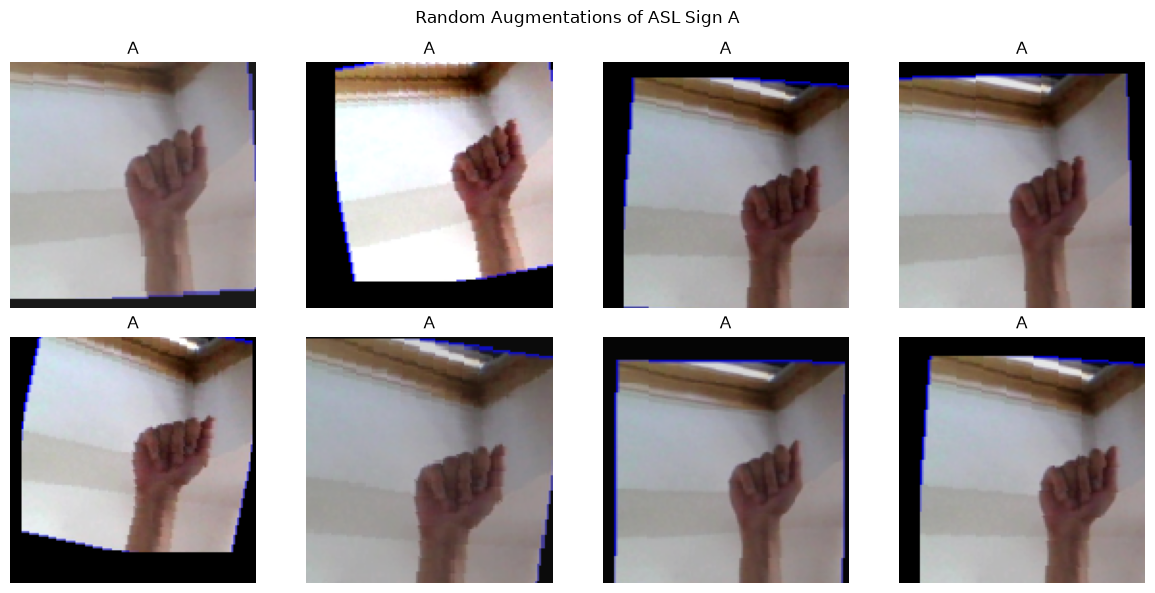

In [16]:
# Visualize augmented training samples

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flatten():

    image_tensor, label_id = train_dataset[0]

    # Convert tensor from CHW -> HWC
    image = image_tensor.permute(1, 2, 0).numpy()

    # Undo normalization [-1, 1] -> [0, 1]
    image = (image * 0.5) + 0.5

    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(idx_to_class[label_id])
    ax.axis("off")

plt.suptitle("Random Augmentations of ASL Sign A")
plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("Matplotlib + NumPy loaded ✅")

Matplotlib + NumPy loaded ✅


In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("Matplotlib:", plt.matplotlib.__version__)
print("NumPy:", np.__version__)
print("Visualization libraries ready ✅")

Matplotlib: 3.11.1
NumPy: 2.5.2
Visualization libraries ready ✅


In [19]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nDataset splits loaded successfully ✅")

Training images: 69600
Validation images: 8700
Test images: 8700

Dataset splits loaded successfully ✅


In [20]:
class_names = sorted(train_df["label"].unique())

class_to_idx = {
    label: idx
    for idx, label in enumerate(class_names)
}

idx_to_class = {
    idx: label
    for label, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))

print("\nClass mapping:")
for label, idx in class_to_idx.items():
    print(f"{idx:2d} -> {label}")

print("\nClass mapping created successfully ✅")

Number of classes: 29

Class mapping:
 0 -> A
 1 -> B
 2 -> C
 3 -> D
 4 -> E
 5 -> F
 6 -> G
 7 -> H
 8 -> I
 9 -> J
10 -> K
11 -> L
12 -> M
13 -> N
14 -> O
15 -> P
16 -> Q
17 -> R
18 -> S
19 -> T
20 -> U
21 -> V
22 -> W
23 -> X
24 -> Y
25 -> Z
26 -> del
27 -> nothing
28 -> space

Class mapping created successfully ✅


In [21]:
from torchvision import transforms

IMG_SIZE = 128

# Training images → augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(12),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


# Validation/Test → no random augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Image size:", IMG_SIZE)
print("Training augmentation ready ✅")
print("Validation/Test preprocessing ready ✅")

Image size: 128
Training augmentation ready ✅
Validation/Test preprocessing ready ✅


In [22]:
from PIL import Image
from torch.utils.data import Dataset


class ASLDataset(Dataset):

    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        label_name = row["label"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform:
            image = self.transform(image)

        # Convert label name to class ID
        label = self.class_to_idx[label_name]

        return image, label


print("ASLDataset class created successfully ✅")

ASLDataset class created successfully ✅


In [23]:
train_dataset = ASLDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)

val_dataset = ASLDataset(
    val_df,
    class_to_idx,
    transform=eval_transform
)

test_dataset = ASLDataset(
    test_df,
    class_to_idx,
    transform=eval_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("\nPyTorch datasets created successfully ✅")

Training dataset: 69600
Validation dataset: 8700
Test dataset: 8700

PyTorch datasets created successfully ✅


In [24]:
image_tensor, label_id = train_dataset[0]

print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)

print("Label ID:", label_id)
print("Label:", idx_to_class[label_id])

print(
    "Tensor range:",
    round(image_tensor.min().item(), 3),
    "to",
    round(image_tensor.max().item(), 3)
)

print("\nAugmented image loaded successfully ✅")

Tensor shape: torch.Size([3, 128, 128])
Tensor dtype: torch.float32
Label ID: 0
Label: A
Tensor range: -0.89 to 0.561

Augmented image loaded successfully ✅


In [25]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nDataLoaders created successfully ✅")

Batch size: 64
Training batches: 1088
Validation batches: 136
Test batches: 136

DataLoaders created successfully ✅


In [26]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("First label ID:", labels[0].item())
print("First label:", idx_to_class[labels[0].item()])

print("\nFirst training batch loaded successfully ✅")

Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
First label ID: 10
First label: K

First training batch loaded successfully ✅


In [27]:
import torch

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Selected device:", device)

# Move one batch to GPU
images_gpu = images.to(device)
labels_gpu = labels.to(device)

print("Images device:", images_gpu.device)
print("Labels device:", labels_gpu.device)

print("GPU batch shape:", images_gpu.shape)

print("\nApple GPU batch test successful ✅")

Selected device: mps
Images device: mps:0
Labels device: mps:0
GPU batch shape: torch.Size([64, 3, 128, 128])

Apple GPU batch test successful ✅


In [28]:
import torch.nn as nn


class SignSpeakCNN(nn.Module):

    def __init__(self, num_classes=29):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(

            # 128x128 -> 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )


    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = SignSpeakCNN(
    num_classes=len(class_names)
)

model = model.to(device)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n" + "=" * 45)
print("SIGNSPEAK CNN")
print("=" * 45)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Device:", device)

print("\nCNN model created successfully ✅")

SignSpeakCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [29]:
model.eval()

with torch.no_grad():
    outputs = model(images_gpu)

print("Input batch shape:", images_gpu.shape)
print("CNN output shape:", outputs.shape)

print("Number of images:", outputs.shape[0])
print("Predictions per image:", outputs.shape[1])

print("\nCNN forward pass successful ✅")

Input batch shape: torch.Size([64, 3, 128, 128])
CNN output shape: torch.Size([64, 29])
Number of images: 64
Predictions per image: 29

CNN forward pass successful ✅


In [30]:
import torch.optim as optim

# Loss function for 29-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)
print("Device:", device)

print("\nTraining configuration ready ✅")

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Device: mps

Training configuration ready ✅


In [31]:
# One-batch training test

model.train()

test_images, test_labels = next(iter(train_loader))

test_images = test_images.to(device)
test_labels = test_labels.to(device)

# Clear old gradients
optimizer.zero_grad()

# Forward pass
outputs = model(test_images)

# Compute loss
loss = criterion(outputs, test_labels)

# Backpropagation
loss.backward()

# Update weights
optimizer.step()

print("One-batch training test completed ✅")
print("Batch size:", test_images.shape[0])
print("Loss:", round(loss.item(), 4))
print("Device:", test_images.device)

One-batch training test completed ✅
Batch size: 64
Loss: 3.4029
Device: mps:0


In [32]:
import time


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        # Progress every 100 batches
        if (batch_idx + 1) % 100 == 0:

            print(
                f"Batch {batch_idx + 1}/{len(loader)} "
                f"| Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = (
        100 * correct / total
    )

    elapsed = time.time() - start_time

    return epoch_loss, epoch_accuracy, elapsed


print("Training function created successfully ✅")

Training function created successfully ✅


In [33]:
def validate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    val_loss = running_loss / len(loader)

    val_accuracy = (
        100 * correct / total
    )

    return val_loss, val_accuracy


print("Validation function created successfully ✅")

Validation function created successfully ✅


In [34]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 1")
print("=" * 55)

train_loss, train_accuracy, train_time = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Training Time: {train_time:.2f} seconds")

print("\nRunning validation...")

val_loss, val_accuracy = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 1 RESULTS")
print("=" * 55)

print(f"Training Loss:     {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Validation Loss:   {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 1
Batch 100/1088 | Loss: 3.3878
Batch 200/1088 | Loss: 3.2797
Batch 300/1088 | Loss: 3.3100
Batch 400/1088 | Loss: 3.0693
Batch 500/1088 | Loss: 3.0160
Batch 600/1088 | Loss: 3.0103
Batch 700/1088 | Loss: 3.0176
Batch 800/1088 | Loss: 2.8889
Batch 900/1088 | Loss: 2.8788
Batch 1000/1088 | Loss: 2.8562

Training completed ✅
Training Loss: 3.1120
Training Accuracy: 9.63%
Training Time: 217.05 seconds

Running validation...

EPOCH 1 RESULTS
Training Loss:     3.1120
Training Accuracy: 9.63%
Validation Loss:   2.3165
Validation Accuracy: 32.40%


In [35]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 2")
print("=" * 55)

train_loss_2, train_accuracy_2, train_time_2 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_2:.4f}")
print(f"Training Accuracy: {train_accuracy_2:.2f}%")
print(f"Training Time: {train_time_2:.2f} seconds")

print("\nRunning validation...")

val_loss_2, val_accuracy_2 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 2 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_2:.4f}")
print(f"Training Accuracy:   {train_accuracy_2:.2f}%")
print(f"Validation Loss:     {val_loss_2:.4f}")
print(f"Validation Accuracy: {val_accuracy_2:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 2
Batch 100/1088 | Loss: 2.6885
Batch 200/1088 | Loss: 2.7684
Batch 300/1088 | Loss: 2.7712
Batch 400/1088 | Loss: 2.8764
Batch 500/1088 | Loss: 2.6454
Batch 600/1088 | Loss: 2.4222
Batch 700/1088 | Loss: 2.5735
Batch 800/1088 | Loss: 2.5436
Batch 900/1088 | Loss: 2.6852
Batch 1000/1088 | Loss: 2.4947

Training completed ✅
Training Loss: 2.6109
Training Accuracy: 16.84%
Training Time: 232.32 seconds

Running validation...

EPOCH 2 RESULTS
Training Loss:       2.6109
Training Accuracy:   16.84%
Validation Loss:     1.6756
Validation Accuracy: 46.28%


In [36]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 3")
print("=" * 55)

train_loss_3, train_accuracy_3, train_time_3 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_3:.4f}")
print(f"Training Accuracy: {train_accuracy_3:.2f}%")
print(f"Training Time: {train_time_3:.2f} seconds")

print("\nRunning validation...")

val_loss_3, val_accuracy_3 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 3 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_3:.4f}")
print(f"Training Accuracy:   {train_accuracy_3:.2f}%")
print(f"Validation Loss:     {val_loss_3:.4f}")
print(f"Validation Accuracy: {val_accuracy_3:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 3
Batch 100/1088 | Loss: 2.4113
Batch 200/1088 | Loss: 2.4032
Batch 300/1088 | Loss: 2.4400
Batch 400/1088 | Loss: 2.3119
Batch 500/1088 | Loss: 2.2611
Batch 600/1088 | Loss: 2.2198
Batch 700/1088 | Loss: 2.3673
Batch 800/1088 | Loss: 2.3604
Batch 900/1088 | Loss: 2.6152
Batch 1000/1088 | Loss: 2.3115

Training completed ✅
Training Loss: 2.4104
Training Accuracy: 21.98%
Training Time: 232.81 seconds

Running validation...

EPOCH 3 RESULTS
Training Loss:       2.4104
Training Accuracy:   21.98%
Validation Loss:     1.4737
Validation Accuracy: 60.92%


In [37]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 4")
print("=" * 55)

train_loss_4, train_accuracy_4, train_time_4 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_4:.4f}")
print(f"Training Accuracy: {train_accuracy_4:.2f}%")
print(f"Training Time: {train_time_4:.2f} seconds")

print("\nRunning validation...")

val_loss_4, val_accuracy_4 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 4 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_4:.4f}")
print(f"Training Accuracy:   {train_accuracy_4:.2f}%")
print(f"Validation Loss:     {val_loss_4:.4f}")
print(f"Validation Accuracy: {val_accuracy_4:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 4
Batch 100/1088 | Loss: 2.1442
Batch 200/1088 | Loss: 2.4201
Batch 300/1088 | Loss: 2.2630
Batch 400/1088 | Loss: 2.5444
Batch 500/1088 | Loss: 2.1834
Batch 600/1088 | Loss: 2.4000
Batch 700/1088 | Loss: 2.3696
Batch 800/1088 | Loss: 2.4436
Batch 900/1088 | Loss: 2.2319
Batch 1000/1088 | Loss: 2.3527

Training completed ✅
Training Loss: 2.2848
Training Accuracy: 25.51%
Training Time: 236.36 seconds

Running validation...

EPOCH 4 RESULTS
Training Loss:       2.2848
Training Accuracy:   25.51%
Validation Loss:     1.2387
Validation Accuracy: 68.55%


In [38]:
from pathlib import Path

CHECKPOINT_DIR = Path("../models/trained")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_epoch4.pth"

torch.save({
    "epoch": 4,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_4,
    "train_accuracy": train_accuracy_4,

    "val_loss": val_loss_4,
    "val_accuracy": val_accuracy_4,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Checkpoint saved successfully ✅")
print("Path:", checkpoint_path)
print("Validation Accuracy:", val_accuracy_4)

Checkpoint saved successfully ✅
Path: ../models/trained/signspeak_cnn_epoch4.pth
Validation Accuracy: 68.55172413793103


In [39]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 5")
print("=" * 55)

train_loss_5, train_accuracy_5, train_time_5 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_5:.4f}")
print(f"Training Accuracy: {train_accuracy_5:.2f}%")
print(f"Training Time: {train_time_5:.2f} seconds")

print("\nRunning validation...")

val_loss_5, val_accuracy_5 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 5 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_5:.4f}")
print(f"Training Accuracy:   {train_accuracy_5:.2f}%")
print(f"Validation Loss:     {val_loss_5:.4f}")
print(f"Validation Accuracy: {val_accuracy_5:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 5
Batch 100/1088 | Loss: 2.2971
Batch 200/1088 | Loss: 1.9338
Batch 300/1088 | Loss: 2.1522
Batch 400/1088 | Loss: 1.9122
Batch 500/1088 | Loss: 2.2637
Batch 600/1088 | Loss: 1.9363
Batch 700/1088 | Loss: 1.9509
Batch 800/1088 | Loss: 1.9789
Batch 900/1088 | Loss: 2.1403
Batch 1000/1088 | Loss: 2.2713

Training completed ✅
Training Loss: 2.1102
Training Accuracy: 30.70%
Training Time: 235.03 seconds

Running validation...

EPOCH 5 RESULTS
Training Loss:       2.1102
Training Accuracy:   30.70%
Validation Loss:     1.1065
Validation Accuracy: 72.62%


In [40]:
checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_epoch5.pth"

torch.save({
    "epoch": 5,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_5,
    "train_accuracy": train_accuracy_5,

    "val_loss": val_loss_5,
    "val_accuracy": val_accuracy_5,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Epoch 5 checkpoint saved successfully ✅")
print("Path:", checkpoint_path)
print(f"Validation Accuracy: {val_accuracy_5:.2f}%")

Epoch 5 checkpoint saved successfully ✅
Path: ../models/trained/signspeak_cnn_epoch5.pth
Validation Accuracy: 72.62%


In [41]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 6")
print("=" * 55)

train_loss_6, train_accuracy_6, train_time_6 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_6:.4f}")
print(f"Training Accuracy: {train_accuracy_6:.2f}%")
print(f"Training Time: {train_time_6:.2f} seconds")

print("\nRunning validation...")

val_loss_6, val_accuracy_6 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 6 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_6:.4f}")
print(f"Training Accuracy:   {train_accuracy_6:.2f}%")
print(f"Validation Loss:     {val_loss_6:.4f}")
print(f"Validation Accuracy: {val_accuracy_6:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 6
Batch 100/1088 | Loss: 2.0688
Batch 200/1088 | Loss: 1.9768
Batch 300/1088 | Loss: 1.9102
Batch 400/1088 | Loss: 2.2658
Batch 500/1088 | Loss: 2.0511
Batch 600/1088 | Loss: 1.9906
Batch 700/1088 | Loss: 2.0330
Batch 800/1088 | Loss: 2.0313
Batch 900/1088 | Loss: 1.9444
Batch 1000/1088 | Loss: 2.0212

Training completed ✅
Training Loss: 2.0032
Training Accuracy: 34.33%
Training Time: 193.17 seconds

Running validation...

EPOCH 6 RESULTS
Training Loss:       2.0032
Training Accuracy:   34.33%
Validation Loss:     0.9153
Validation Accuracy: 79.06%


In [42]:
checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_epoch6.pth"

torch.save({
    "epoch": 6,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_6,
    "train_accuracy": train_accuracy_6,

    "val_loss": val_loss_6,
    "val_accuracy": val_accuracy_6,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Epoch 6 checkpoint saved successfully ✅")
print("Path:", checkpoint_path)
print(f"Validation Accuracy: {val_accuracy_6:.2f}%")

Epoch 6 checkpoint saved successfully ✅
Path: ../models/trained/signspeak_cnn_epoch6.pth
Validation Accuracy: 79.06%


In [43]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 7")
print("=" * 55)

train_loss_7, train_accuracy_7, train_time_7 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_7:.4f}")
print(f"Training Accuracy: {train_accuracy_7:.2f}%")
print(f"Training Time: {train_time_7:.2f} seconds")

print("\nRunning validation...")

val_loss_7, val_accuracy_7 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 7 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_7:.4f}")
print(f"Training Accuracy:   {train_accuracy_7:.2f}%")
print(f"Validation Loss:     {val_loss_7:.4f}")
print(f"Validation Accuracy: {val_accuracy_7:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 7
Batch 100/1088 | Loss: 1.9318
Batch 200/1088 | Loss: 1.7905
Batch 300/1088 | Loss: 1.7987
Batch 400/1088 | Loss: 1.5710
Batch 500/1088 | Loss: 1.7960
Batch 600/1088 | Loss: 1.7301
Batch 700/1088 | Loss: 1.9161
Batch 800/1088 | Loss: 1.6770
Batch 900/1088 | Loss: 1.7133
Batch 1000/1088 | Loss: 1.7713

Training completed ✅
Training Loss: 1.8361
Training Accuracy: 39.09%
Training Time: 203.85 seconds

Running validation...

EPOCH 7 RESULTS
Training Loss:       1.8361
Training Accuracy:   39.09%
Validation Loss:     0.7914
Validation Accuracy: 83.20%


In [44]:
checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_epoch7.pth"

torch.save({
    "epoch": 7,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_7,
    "train_accuracy": train_accuracy_7,

    "val_loss": val_loss_7,
    "val_accuracy": val_accuracy_7,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Epoch 7 checkpoint saved successfully ✅")
print("Path:", checkpoint_path)
print(f"Validation Accuracy: {val_accuracy_7:.2f}%")

Epoch 7 checkpoint saved successfully ✅
Path: ../models/trained/signspeak_cnn_epoch7.pth
Validation Accuracy: 83.20%


In [45]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 8")
print("=" * 55)

train_loss_8, train_accuracy_8, train_time_8 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_8:.4f}")
print(f"Training Accuracy: {train_accuracy_8:.2f}%")
print(f"Training Time: {train_time_8:.2f} seconds")

print("\nRunning validation...")

val_loss_8, val_accuracy_8 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 8 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_8:.4f}")
print(f"Training Accuracy:   {train_accuracy_8:.2f}%")
print(f"Validation Loss:     {val_loss_8:.4f}")
print(f"Validation Accuracy: {val_accuracy_8:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 8
Batch 100/1088 | Loss: 1.5303
Batch 200/1088 | Loss: 1.5981
Batch 300/1088 | Loss: 1.6719
Batch 400/1088 | Loss: 1.3375
Batch 500/1088 | Loss: 1.6575
Batch 600/1088 | Loss: 1.0890
Batch 700/1088 | Loss: 1.1564
Batch 800/1088 | Loss: 0.9895
Batch 900/1088 | Loss: 0.9877
Batch 1000/1088 | Loss: 1.2948

Training completed ✅
Training Loss: 1.4145
Training Accuracy: 51.33%
Training Time: 219.12 seconds

Running validation...

EPOCH 8 RESULTS
Training Loss:       1.4145
Training Accuracy:   51.33%
Validation Loss:     0.3847
Validation Accuracy: 91.62%


In [46]:
checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_best.pth"

torch.save({
    "epoch": 8,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_8,
    "train_accuracy": train_accuracy_8,

    "val_loss": val_loss_8,
    "val_accuracy": val_accuracy_8,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Best CNN model saved successfully ✅")
print("Path:", checkpoint_path)
print(f"Validation Accuracy: {val_accuracy_8:.2f}%")

Best CNN model saved successfully ✅
Path: ../models/trained/signspeak_cnn_best.pth
Validation Accuracy: 91.62%


In [48]:
model.eval()

test_correct = 0
test_total = 0
test_loss_sum = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss_sum += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()


test_loss = test_loss_sum / len(test_loader)
test_accuracy = 100 * test_correct / test_total

print("=" * 55)
print("SIGNSPEAK CNN — FINAL TEST EVALUATION")
print("=" * 55)

print("Test samples:", test_total)
print("Correct predictions:", test_correct)
print("Incorrect predictions:", test_total - test_correct)

print(f"Test Loss: {test_loss:.4f}")
print(f"Final CNN Test Accuracy: {test_accuracy:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — FINAL TEST EVALUATION
Test samples: 8700
Correct predictions: 7915
Incorrect predictions: 785
Test Loss: 0.3929
Final CNN Test Accuracy: 90.98%


In [49]:
from PIL import Image

CUSTOM_DIR = Path("../data/custom_test")

custom_tests = [
    ("A", CUSTOM_DIR / "my_A.jpg"),
    ("B", CUSTOM_DIR / "my_B.jpg"),
    ("C", CUSTOM_DIR / "my_C.jpg"),
    ("L", CUSTOM_DIR / "my_L.jpg"),
    ("V", CUSTOM_DIR / "my_V.jpg"),
]

model.eval()

correct = 0
total = 0

print("=" * 60)
print("SIGNSPEAK CNN — EXTERNAL IMAGE TEST")
print("=" * 60)

with torch.no_grad():

    for expected, image_path in custom_tests:

        if not image_path.exists():
            print(f"{image_path.name}: FILE NOT FOUND ❌")
            continue

        image = Image.open(image_path).convert("RGB")

        # Same preprocessing used for validation/test
        tensor = eval_transform(image)
        tensor = tensor.unsqueeze(0).to(device)

        outputs = model(tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_id = torch.max(
            probabilities,
            dim=1
        )

        predicted = idx_to_class[
            predicted_id.item()
        ]

        confidence = confidence.item() * 100

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        total += 1

        print(
            f"{image_path.name:12} "
            f"Expected: {expected:2} | "
            f"Predicted: {predicted:8} | "
            f"Confidence: {confidence:6.2f}% | "
            f"{'✅' if is_correct else '❌'}"
        )

print("=" * 60)

accuracy = 100 * correct / total if total else 0

print(f"Correct predictions: {correct}/{total}")
print(f"External Image Accuracy: {accuracy:.2f}%")

print("=" * 60)

SIGNSPEAK CNN — EXTERNAL IMAGE TEST
my_A.jpg     Expected: A  | Predicted: N        | Confidence:  46.04% | ❌
my_B.jpg     Expected: B  | Predicted: E        | Confidence:  43.37% | ❌
my_C.jpg     Expected: C  | Predicted: O        | Confidence:  56.65% | ❌
my_L.jpg     Expected: L  | Predicted: Q        | Confidence:  82.06% | ❌
my_V.jpg     Expected: V  | Predicted: K        | Confidence:  57.06% | ❌
Correct predictions: 0/5
External Image Accuracy: 0.00%


In [50]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "HOG + Linear SVM",
        "CNN + Data Augmentation"
    ],
    "Validation Accuracy (%)": [
        91.14,
        91.62
    ],
    "Test Accuracy (%)": [
        91.09,
        90.98
    ],
    "External Accuracy (%)": [
        0.0,
        0.0
    ]
})

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    RESULTS_DIR / "cnn_model_comparison.csv",
    index=False
)

print(comparison.to_string(index=False))
print("\nModel comparison saved successfully ✅")

                  Model  Validation Accuracy (%)  Test Accuracy (%)  External Accuracy (%)
       HOG + Linear SVM                    91.14              91.09                    0.0
CNN + Data Augmentation                    91.62              90.98                    0.0

Model comparison saved successfully ✅


In [51]:
external_results = pd.DataFrame({
    "Expected": ["A", "B", "C", "L", "V"],
    "Predicted": ["N", "E", "O", "Q", "K"],
    "Confidence (%)": [46.04, 43.37, 56.65, 82.06, 57.06],
    "Correct": [False, False, False, False, False]
})

external_results.to_csv(
    RESULTS_DIR / "cnn_external_test_results.csv",
    index=False
)

print(external_results.to_string(index=False))

print("\nExternal test results saved successfully ✅")

Expected Predicted  Confidence (%)  Correct
       A         N           46.04    False
       B         E           43.37    False
       C         O           56.65    False
       L         Q           82.06    False
       V         K           57.06    False

External test results saved successfully ✅


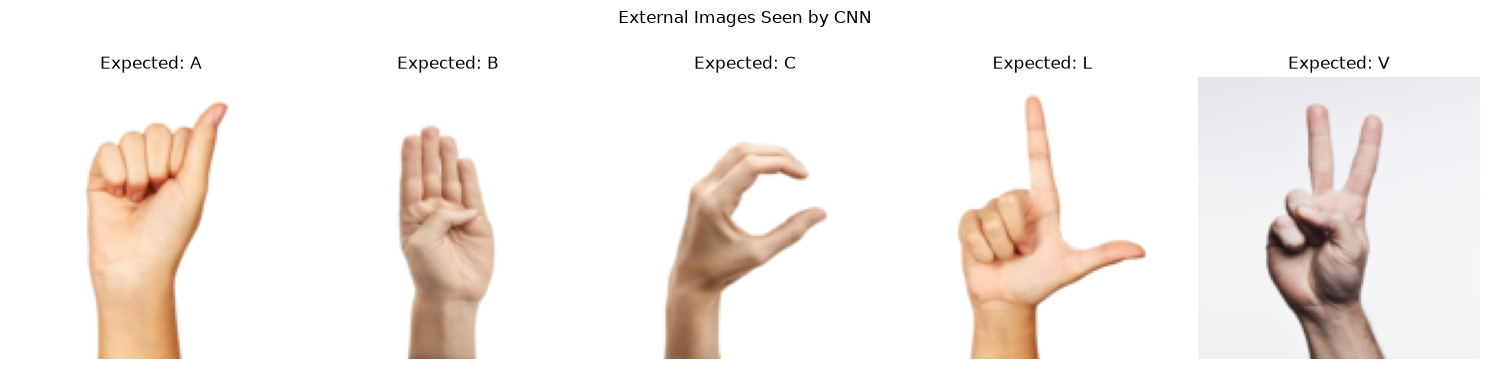

In [52]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

custom_tests = [
    ("A", Path("../data/custom_test/my_A.jpg")),
    ("B", Path("../data/custom_test/my_B.jpg")),
    ("C", Path("../data/custom_test/my_C.jpg")),
    ("L", Path("../data/custom_test/my_L.jpg")),
    ("V", Path("../data/custom_test/my_V.jpg")),
]

for ax, (label, image_path) in zip(axes, custom_tests):

    image = Image.open(image_path).convert("RGB")

    tensor = eval_transform(image)

    # CHW -> HWC
    display_image = tensor.permute(1, 2, 0).numpy()

    # Undo normalization
    display_image = (display_image * 0.5) + 0.5
    display_image = np.clip(display_image, 0, 1)

    ax.imshow(display_image)
    ax.set_title(f"Expected: {label}")
    ax.axis("off")

plt.suptitle("External Images Seen by CNN")
plt.tight_layout()
plt.show()

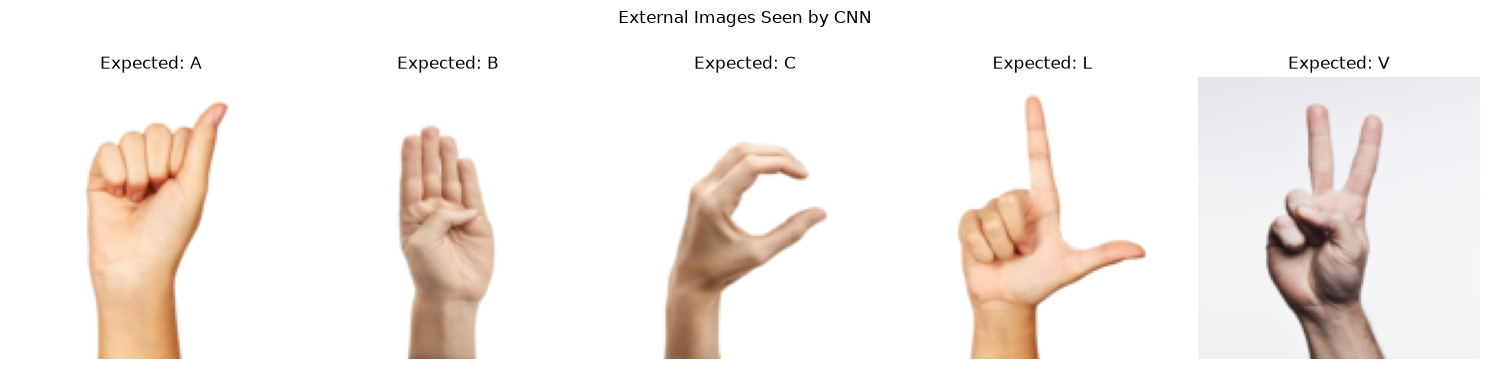

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

custom_tests = [
    ("A", Path("../data/custom_test/my_A.jpg")),
    ("B", Path("../data/custom_test/my_B.jpg")),
    ("C", Path("../data/custom_test/my_C.jpg")),
    ("L", Path("../data/custom_test/my_L.jpg")),
    ("V", Path("../data/custom_test/my_V.jpg")),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, (label, image_path) in zip(axes, custom_tests):

    image = Image.open(image_path).convert("RGB")
    tensor = eval_transform(image)

    display_image = tensor.permute(1, 2, 0).numpy()

    # Undo normalization
    display_image = (display_image * 0.5) + 0.5
    display_image = np.clip(display_image, 0, 1)

    ax.imshow(display_image)
    ax.set_title(f"Expected: {label}")
    ax.axis("off")

plt.suptitle("External Images Seen by CNN")
plt.tight_layout()
plt.show()

In [54]:
from torchvision import transforms

external_transform = transforms.Compose([
    transforms.Resize(160),
    transforms.CenterCrop(128),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("External-image preprocessing created ✅")

External-image preprocessing created ✅


In [55]:
model.eval()

correct = 0
total = 0

print("=" * 60)
print("SIGNSPEAK CNN — EXTERNAL TEST WITH CENTER CROP")
print("=" * 60)

with torch.no_grad():

    for expected, image_path in custom_tests:

        image = Image.open(image_path).convert("RGB")

        tensor = external_transform(image)
        tensor = tensor.unsqueeze(0).to(device)

        outputs = model(tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_id = torch.max(
            probabilities,
            dim=1
        )

        predicted = idx_to_class[predicted_id.item()]
        confidence = confidence.item() * 100

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        total += 1

        print(
            f"{image_path.name:12} "
            f"Expected: {expected:2} | "
            f"Predicted: {predicted:8} | "
            f"Confidence: {confidence:6.2f}% | "
            f"{'✅' if is_correct else '❌'}"
        )

print("=" * 60)

accuracy = 100 * correct / total

print(f"Correct predictions: {correct}/{total}")
print(f"External Accuracy: {accuracy:.2f}%")

print("=" * 60)

SIGNSPEAK CNN — EXTERNAL TEST WITH CENTER CROP
my_A.jpg     Expected: A  | Predicted: N        | Confidence:  52.95% | ❌
my_B.jpg     Expected: B  | Predicted: E        | Confidence:  74.28% | ❌
my_C.jpg     Expected: C  | Predicted: Q        | Confidence:  66.18% | ❌
my_L.jpg     Expected: L  | Predicted: Q        | Confidence:  60.61% | ❌
my_V.jpg     Expected: V  | Predicted: K        | Confidence:  90.53% | ❌
Correct predictions: 0/5
External Accuracy: 0.00%


In [56]:
from torchvision import transforms

IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((144, 144)),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.75, 1.0),
        ratio=(0.85, 1.15)
    ),

    transforms.RandomRotation(18),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.85, 1.15),
        shear=8
    ),

    transforms.ColorJitter(
        brightness=0.35,
        contrast=0.35,
        saturation=0.25,
        hue=0.05
    ),

    transforms.RandomPerspective(
        distortion_scale=0.15,
        p=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Stronger augmentation ready ✅")

Stronger augmentation ready ✅


In [57]:
train_dataset = ASLDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Training dataset recreated ✅")
print("Training images:", len(train_dataset))
print("Training batches:", len(train_loader))

Training dataset recreated ✅
Training images: 69600
Training batches: 1088


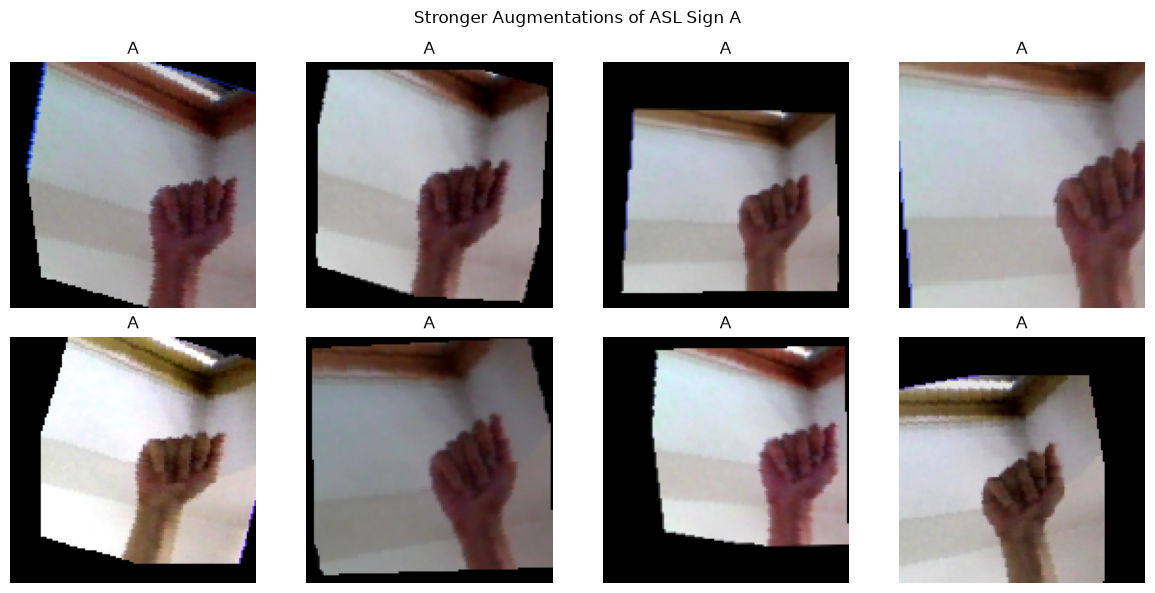

In [58]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flatten():

    image_tensor, label_id = train_dataset[0]

    image = image_tensor.permute(1, 2, 0).numpy()

    # Undo normalization
    image = (image * 0.5) + 0.5
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(idx_to_class[label_id])
    ax.axis("off")

plt.suptitle("Stronger Augmentations of ASL Sign A")
plt.tight_layout()
plt.show()

In [59]:
print("=" * 55)
print("SIGNSPEAK CNN — EPOCH 9 (STRONG AUGMENTATION)")
print("=" * 55)

train_loss_9, train_accuracy_9, train_time_9 = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("\nTraining completed ✅")
print(f"Training Loss: {train_loss_9:.4f}")
print(f"Training Accuracy: {train_accuracy_9:.2f}%")
print(f"Training Time: {train_time_9:.2f} seconds")

print("\nRunning validation...")

val_loss_9, val_accuracy_9 = validate_model(
    model,
    val_loader,
    criterion,
    device
)

print("\n" + "=" * 55)
print("EPOCH 9 RESULTS")
print("=" * 55)

print(f"Training Loss:       {train_loss_9:.4f}")
print(f"Training Accuracy:   {train_accuracy_9:.2f}%")
print(f"Validation Loss:     {val_loss_9:.4f}")
print(f"Validation Accuracy: {val_accuracy_9:.2f}%")

print("=" * 55)

SIGNSPEAK CNN — EPOCH 9 (STRONG AUGMENTATION)
Batch 100/1088 | Loss: 1.7772
Batch 200/1088 | Loss: 1.5755
Batch 300/1088 | Loss: 1.7134
Batch 400/1088 | Loss: 1.4733
Batch 500/1088 | Loss: 1.4526
Batch 600/1088 | Loss: 1.4071
Batch 700/1088 | Loss: 1.3326
Batch 800/1088 | Loss: 1.3834
Batch 900/1088 | Loss: 1.3917
Batch 1000/1088 | Loss: 1.0132

Training completed ✅
Training Loss: 1.4395
Training Accuracy: 52.05%
Training Time: 219.08 seconds

Running validation...

EPOCH 9 RESULTS
Training Loss:       1.4395
Training Accuracy:   52.05%
Validation Loss:     0.3341
Validation Accuracy: 88.97%


In [60]:
model.eval()

correct = 0
total = 0

print("=" * 60)
print("SIGNSPEAK CNN — EXTERNAL TEST AFTER STRONG AUGMENTATION")
print("=" * 60)

with torch.no_grad():

    for expected, image_path in custom_tests:

        image = Image.open(image_path).convert("RGB")

        tensor = eval_transform(image)
        tensor = tensor.unsqueeze(0).to(device)

        outputs = model(tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_id = torch.max(
            probabilities,
            dim=1
        )

        predicted = idx_to_class[predicted_id.item()]
        confidence = confidence.item() * 100

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        total += 1

        print(
            f"{image_path.name:12} "
            f"Expected: {expected:2} | "
            f"Predicted: {predicted:8} | "
            f"Confidence: {confidence:6.2f}% | "
            f"{'✅' if is_correct else '❌'}"
        )

print("=" * 60)

accuracy = 100 * correct / total

print(f"Correct predictions: {correct}/{total}")
print(f"External Accuracy: {accuracy:.2f}%")

print("=" * 60)

SIGNSPEAK CNN — EXTERNAL TEST AFTER STRONG AUGMENTATION
my_A.jpg     Expected: A  | Predicted: N        | Confidence:  43.18% | ❌
my_B.jpg     Expected: B  | Predicted: E        | Confidence:  54.43% | ❌
my_C.jpg     Expected: C  | Predicted: C        | Confidence:  92.02% | ✅
my_L.jpg     Expected: L  | Predicted: C        | Confidence:  63.36% | ❌
my_V.jpg     Expected: V  | Predicted: I        | Confidence:  81.38% | ❌
Correct predictions: 1/5
External Accuracy: 20.00%


In [61]:
checkpoint_path = CHECKPOINT_DIR / "signspeak_cnn_epoch9_strong_aug.pth"

torch.save({
    "epoch": 9,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss_9,
    "train_accuracy": train_accuracy_9,

    "val_loss": val_loss_9,
    "val_accuracy": val_accuracy_9,

    "external_accuracy": 20.0,

    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE
}, checkpoint_path)

print("Epoch 9 strong-augmentation model saved ✅")
print("Path:", checkpoint_path)
print(f"Validation Accuracy: {val_accuracy_9:.2f}%")
print("External Accuracy: 20.00%")

Epoch 9 strong-augmentation model saved ✅
Path: ../models/trained/signspeak_cnn_epoch9_strong_aug.pth
Validation Accuracy: 88.97%
External Accuracy: 20.00%
